# Stat Chronodel

The project that I am working on is to analyze the data of the Chronodel test, which is a test that measures the ability to perform a task in a delimation of time of 30 seconds. The data is collected from a sample of participants who have taken the test (n = 43). The goal of this analysis is to experiment the test Chronodel understand the distribution of the results and to compare the results of the Chronodel test with other tests that measure similar abilities, by others, i mean, Day Of the Week Backward and (DOTWB) and Month Of The Year Backward (MOTYB).

At the beggining of the analysis, we wanted to calculate the sensibility, specificity, positive predictive value and negative predictive value of the Chronodel test, but at the reception of the results, we saw, that there are a variability in the results of the Chronodel test, which is really low, and that the majority of the patients have a result of 1 on the Chronodel test, which means that they succeed the test, because we expected to have a more variability in the results, and also because we expected to have a lower success rate for the Chronodel test, so we decided to change our analysis plan and to focus on pourcentage of success for the three tests (DOTWB, MOTYB) to evaluate the coherence between the results and at the end, the distribution of the results for the three tests, to evaluate the variability and the ceiling effect.

In [2]:
import pandas as pd

Data = pd.read_csv("ChronodelSansTNC_DATA_2026-03-30_1433.csv")
Data.head()

,record_id,redcap_repeat_instrument,redcap_repeat_instance,redcap_survey_identifier,chronodel_sans_tnc_timestamp,mail,date_inclusion,date_evalution,num_inclusion,age_inclusion,...,chrono_arrettrente,chrono_trente,mmse,mmse_orientation,mmse_apprenti,mmsse_calcul,mmse_rappel,mmse_langage,mmse_praxies,chronodel_sans_tnc_complete
0,1,chronodel_sans_tnc,1,NaN,2026-02-05 13:57:25,valery.antoine@chu-nimes.fr,2025-12-09,2025-12-09,C03P012,92,...,NaN,NaN,20,7,3,2,0.0,7,1,2
1,1,chronodel_sans_tnc,2,NaN,2026-02-05 14:18:30,valery.antoine@chu-nimes.fr,2025-11-19,2025-11-19,C03P011,86,...,NaN,NaN,28,10,3,5,1.0,8,1,2
2,1,chronodel_sans_tnc,3,NaN,2026-02-05 14:46:53,valery.antoine@chu-nimes.fr,2025-12-17,2025-12-17,C03P010,94,...,NaN,NaN,23,8,3,5,0.0,7,0,2
3,1,chronodel_sans_tnc,4,NaN,2026-02-05 15:05:07,valery.antoine@chu-nimes.fr,2025-12-17,2025-12-17,C03P009,98,...,NaN,NaN,20,6,3,4,0.0,6,1,2
4,1,chronodel_sans_tnc,5,NaN,2026-02-05 15:17:28,valery.antoine@chu-nimes.fr,2025-12-10,2025-12-10,C03P008,85,...,NaN,NaN,25,10,3,1,3.0,7,1,2


First of all, we gonna found or file with the data and open it

In [3]:
# Delete the lines 11, 28 and 29
Data = Data.drop([11, 28, 29])

The 3 subjects 11, 28 and 29 were removed from the data because they don't respect the general inclusion criteria of the study, witch is for a hypoacoustic for 11 and 28, for 29, he doesn't understand french language, and the test is in french, so we can't be sure that he understand the instructions of the test, it may appear some bias.

In [9]:
# show me the number of lines
len(Data)

40

At the beginning we got 43 subjetcs that has been reduce to 40 in relation with the 3 out because they don't respect the general inclusion criteria.

In [5]:
# pourcentage of 1 and 0 of jour_reussite, mois_reussi and chrono_reussi
print("Pourcentage de jour_reussite :")
print(Data["jour_reussite"].value_counts(normalize=True) * 100)
print("Pourcentage de mois_reussi :")
print(Data["mois_reussi"].value_counts(normalize=True) * 100)
print("Pourcentage de chrono_reussi :")
print(Data["chrono_reussi"].value_counts(normalize=True) * 100)

Pourcentage de jour_reussite :
jour_reussite
1.0    97.297297
0.0     2.702703
Name: proportion, dtype: float64
Pourcentage de mois_reussi :
mois_reussi
1.0    58.974359
0.0    41.025641
Name: proportion, dtype: float64
Pourcentage de chrono_reussi :
chrono_reussi
1    100.0
Name: proportion, dtype: float64


For our first graph, i will need the pourcentage of subjects with 0 and 1 (no or yes) in the 3 differents test DOTWB and MOTYB.
As a result i got for the first test DOTWB, there is 97.29 % of yes and 2.70 % of no, which mean that we have more than 97 % opf subjects that i've succeed the test.
For the seconde test MOTYB, we have 58.97 % of yes and 41.02 % of no, we have in this case a better balance between the yes and no
For the last test, the one that we want experiment, Chronodel, we've got 100 %  of yes and 0% of no, we have clearly an unbamance result between the subjetcs that have been succeesful to the test and these that were not.

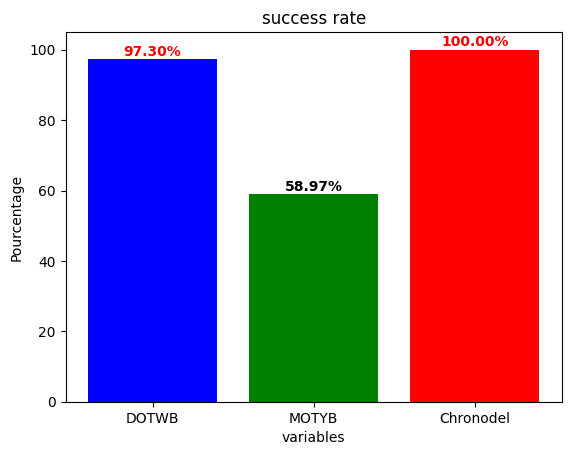

In [6]:
import matplotlib.pyplot as plt

labels = ["DOTWB", "MOTYB", "Chronodel"]
values = [Data["jour_reussite"].value_counts(normalize=True)[1] * 100, Data["mois_reussi"].value_counts(normalize=True)[1] * 100, Data["chrono_reussi"].value_counts(normalize=True)[1] * 100]
color = ["blue", "green", "red"]
for i, v in enumerate(values):
    if v > 95:
        plt.text(i, v + 1, f"{v:.2f}%", ha="center", fontweight="bold", color="red")
    else:
        plt.text(i, v + 1, f"{v:.2f}%", ha="center", fontweight="bold")
plt.bar(labels, values, color=color)
plt.xlabel("variables")
plt.ylabel("Pourcentage")
plt.title("success rate")
plt.show()


As a result of what success rate for the three tests, we can see something particular for the DOTWVB et Chronodel test, both of them have a ceiling effect that eppear, for MOTYB, we have a success rate closer to 50 % than 100 %.

In [10]:
#create a new csv file of the data with only the columns "jour_reussite", "mois_reussi" and "chrono_reussi" with a new name "Stat_Chronodel_Rstudio_test.csv"
Data[["jour_reussite", "mois_reussi", "chrono_reussi"]].to_csv("Stat_Chronodel_Rstudio_test.csv", index=False)